# HW1: Decision trees

In [35]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from sklearn import preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, accuracy_score,\
    confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split
from matplotlib.legend_handler import HandlerLine2D
from sklearn import tree
import seaborn as sns
import graphviz

%pylab inline
figsize(12, 8)

Populating the interactive namespace from numpy and matplotlib


In [3]:
%load_ext pycodestyle_magic

# Loading data from file

In [4]:
df = pd.read_csv("data/titanic_sample.csv")

In [5]:
df.head()

,Survived,Age,Pclass
0,0,29.0,1
1,1,25.0,1
2,0,2.0,3
3,1,36.0,1
4,0,45.0,1


In [6]:
df.describe()

,Survived,Age,Pclass
count,100.000000,100.000000,100.000000
mean,0.600000,36.430000,1.190000
std,0.492366,14.310768,0.525991
min,0.000000,2.000000,1.000000
25%,0.000000,26.500000,1.000000
50%,1.000000,36.000000,1.000000
75%,1.000000,46.250000,1.000000
max,1.000000,70.000000,3.000000


## See what's inside

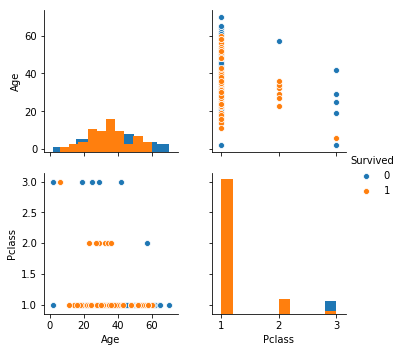

In [7]:
sns.pairplot(df,diag_kind='hist',hue='Survived',vars=['Age','Pclass'])

# Splitting the data

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    df[['Age', 'Pclass']], df['Survived'], test_size=0.3, random_state=42)

## Default parameters

In [12]:
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

DecisionTreeClassifier(class_weight=None, criterion='gini', max_depth=None,
                       max_features=None, max_leaf_nodes=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, presort=False,
                       random_state=None, splitter='best')

In [18]:
y_pred = model.predict_proba(X_test)[:, 1]

## ROC AUC metrics

In [19]:
false_positive_rate, true_positive_rate, thresholds = \
    roc_curve(y_test, y_pred)
roc_auc = auc(false_positive_rate, true_positive_rate)
roc_auc

0.5334928229665072

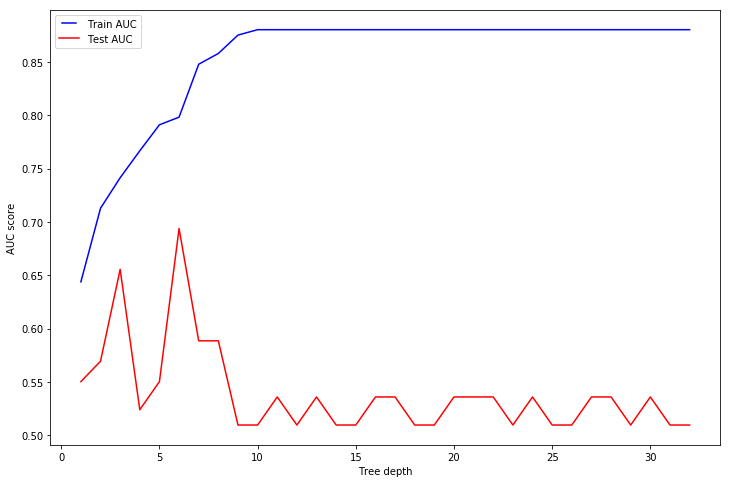

In [25]:
max_depths = np.linspace(1, 32, 32, endpoint=True)
train_results = []
test_results = []
for max_depth in max_depths:
    dt = DecisionTreeClassifier(max_depth=max_depth)
    dt.fit(X_train, y_train)
    train_pred = dt.predict(X_train)
    false_positive_rate, true_positive_rate, thresholds = \
        roc_curve(y_train, train_pred)
    roc_auc = auc(false_positive_rate, true_positive_rate)
    # Add auc score to previous train results
    train_results.append(roc_auc)
    y_pred = dt.predict(X_test)
    false_positive_rate, true_positive_rate, thresholds = \
        roc_curve(y_test, y_pred)
    roc_auc = auc(false_positive_rate, true_positive_rate)
    # Add auc score to previous test results
    test_results.append(roc_auc)
line1, = plt.plot(max_depths, train_results, 'b', label='Train AUC')
line2, = plt.plot(max_depths, test_results, 'r', label='Test AUC')
plt.legend(handler_map={line1: HandlerLine2D(numpoints=2)})
plt.ylabel('AUC score')
plt.xlabel('Tree depth')
plt.show()

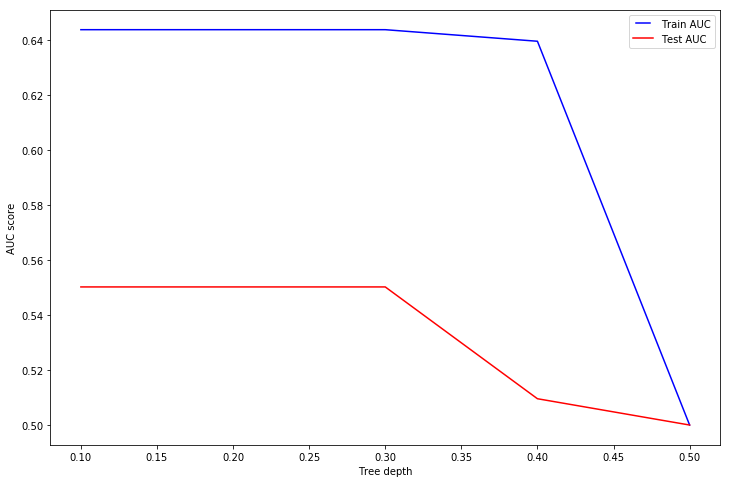

In [28]:
min_samples_leafs = np.linspace(0.1, 0.5, 5, endpoint=True)
train_results = []
test_results = []
for min_s in min_samples_leafs:
    dt = DecisionTreeClassifier(min_samples_leaf=min_s)
    dt.fit(X_train, y_train)
    train_pred = dt.predict(X_train)
    false_positive_rate, true_positive_rate, thresholds = \
        roc_curve(y_train, train_pred)
    roc_auc = auc(false_positive_rate, true_positive_rate)
    # Add auc score to previous train results
    train_results.append(roc_auc)
    y_pred = dt.predict(X_test)
    false_positive_rate, true_positive_rate, thresholds = \
        roc_curve(y_test, y_pred)
    roc_auc = auc(false_positive_rate, true_positive_rate)
    # Add auc score to previous test results
    test_results.append(roc_auc)
line1, = plt.plot(min_samples_leafs, train_results, 'b', label='Train AUC')
line2, = plt.plot(min_samples_leafs, test_results, 'r', label='Test AUC')
plt.legend(handler_map={line1: HandlerLine2D(numpoints=2)})
plt.ylabel('AUC score')
plt.xlabel('Tree depth')
plt.show()

# GridSearchCV

In [32]:
params = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': np.linspace(1, 10, 10, endpoint=True),
    'min_samples_leaf': np.linspace(0.1, 0.3, 10, endpoint=True)
}

best_model = GridSearchCV(DecisionTreeClassifier(),
                          params,
                          verbose=True,
                          n_jobs=-1,
                          cv=5).fit(X_train, y_train)

print(best_model.best_params_)
print(best_model.best_score_)

Fitting 5 folds for each of 400 candidates, totalling 2000 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    1.4s


{'criterion': 'gini', 'max_depth': 4.0, 'min_samples_leaf': 0.14444444444444443, 'splitter': 'random'}
0.6714285714285714


[Parallel(n_jobs=-1)]: Done 1824 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-1)]: Done 1985 out of 2000 | elapsed:    2.9s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done 2000 out of 2000 | elapsed:    2.9s finished


In [33]:
best_model.best_estimator_.feature_importances_

array([1., 0.])

# Visualizing the tree

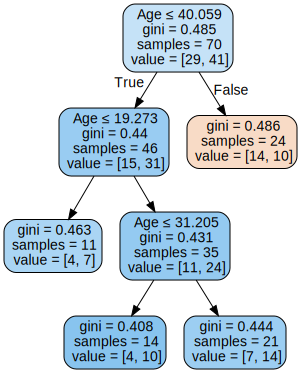

In [46]:
dot_data = tree.export_graphviz(best_model.best_estimator_, out_file=None,
                                feature_names=df.iloc[:, 1:].columns,
                                filled=True, rounded=True,
                                special_characters=True)
graph = graphviz.Source(dot_data)
graph

## Default model parameters

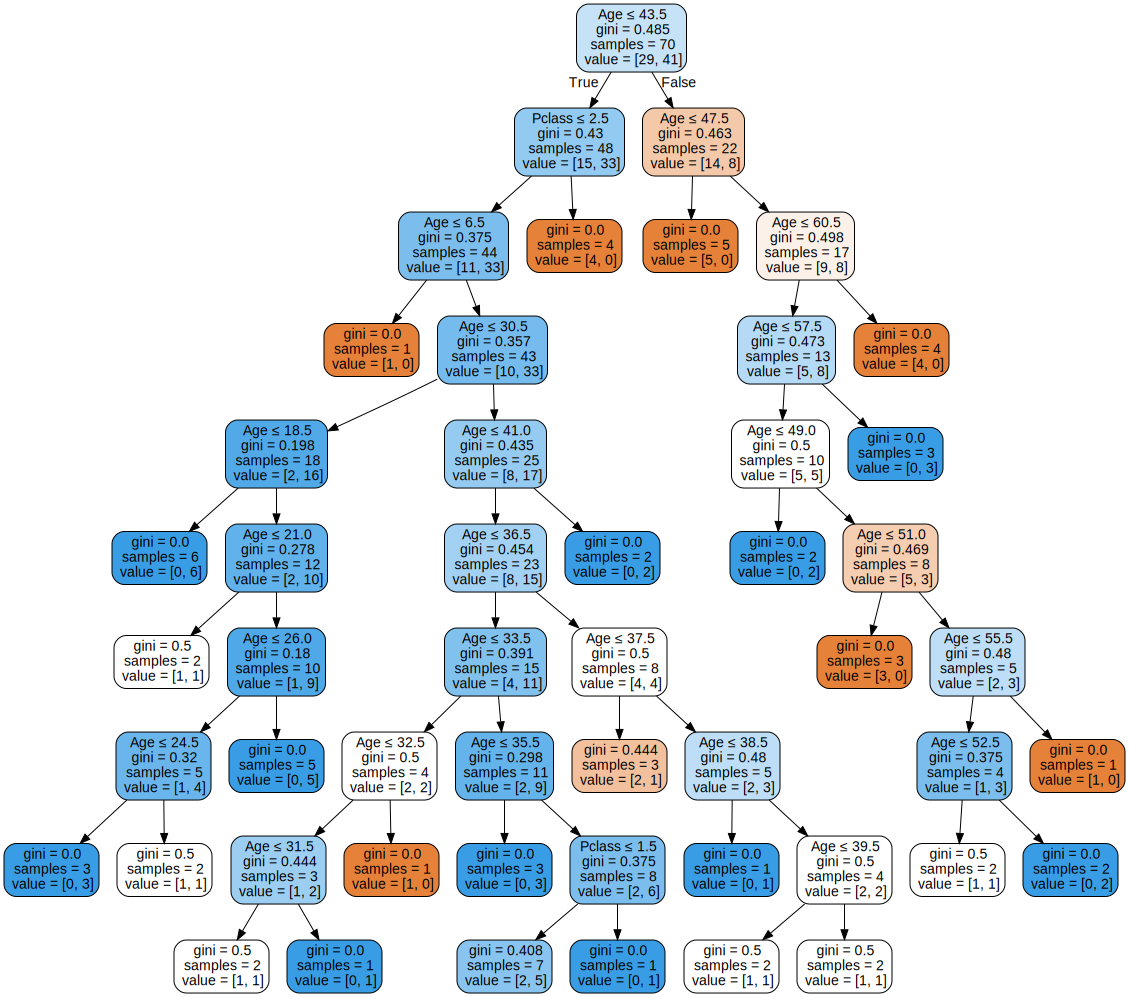

In [42]:
dot_data = tree.export_graphviz(model, out_file=None,
                                feature_names=df.iloc[:, 1:].columns,
                                filled=True, rounded=True,
                                special_characters=True) 
graph = graphviz.Source(dot_data)
graph